# dSprites Autoencoder Comparison: Static vs Developing (Fast Subset Training)

This notebook compares two approaches to training autoencoders on the dSprites dataset:

1. **Static Autoencoder**: Traditional approach with a fixed bottleneck size of 6 dimensions
2. **Developing Autoencoder**: Novel approach where the bottleneck size grows progressively from 1 to 6 dimensions

## Experiment Setup (Optimized for Speed)
- **Dataset**: dSprites subset (50,000 out of 737,280 images - about 7% for faster training)
- **Architecture**: Simplified convolutional autoencoder using `dSpriteAutoencoder` class
- **Static Training**: 10 epochs with bottleneck size = 6 (reduced from 30)
- **Developing Training**: 12 epochs total (2 epochs each for sizes [1,2,3,4,5,6])
- **Evaluation**: Reconstruction loss and disentanglement metrics (MIG, SAP) on 5k samples
- **Expected Speedup**: ~15x faster than full dataset training

## Key Questions
- Does the developing approach achieve better disentanglement even with limited data?
- How do the final reconstruction losses compare with faster training?
- Can we see meaningful differences with this reduced training regime?

## Trade-offs
- **Pros**: Much faster experimentation, quicker iteration on hyperparameters
- **Cons**: Results may not generalize as well as full dataset training
- **Use Case**: Ideal for testing approaches before committing to full-scale experiments

In [1]:
# dSprites Autoencoder Training and Comparison
# ============================================

import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

# Add parent directory to path to import custom modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from autoencoder import dSpriteAutoencoder
from solver import train_vali_all_epochs_conv, dev_train_vali_all_epochs_dSprite, test_conv

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Load and prepare dSprites dataset (SUBSET FOR FASTER TRAINING)
# ==================================================================

# Load dSprites data (memory-mapped for efficiency)
data_path = "/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_development_notebooks/data/dsprites_ndarray_co1sh3sc6or40x32y32_64x64.npz"
arr = np.load(data_path, mmap_mode="r")
images_memmap = arr['imgs']     # (737280, 64, 64)
factors_memmap = arr['latents_classes']  # (737280, 5)

# Use only a small subset for faster training and experimentation
subset_size = 50000  # Use only 50k images instead of 737k (about 7% of dataset)
print(f"Full dataset shape: {images_memmap.shape}")
print(f"Using subset of {subset_size} images for faster training")

# Sample random indices for the subset
np.random.seed(42)  # For reproducibility
subset_indices = np.random.choice(images_memmap.shape[0], size=subset_size, replace=False)
subset_indices = np.sort(subset_indices)  # Sort for better memory access

# Create subset arrays
images_subset = images_memmap[subset_indices]
factors_subset = factors_memmap[subset_indices]
num_examples = subset_size

print(f"Subset dataset shape: {images_subset.shape}")
print(f"Subset factors shape: {factors_subset.shape}")

# Dataset class for dSprites subset
class DSpritesMemmapDataset(torch.utils.data.Dataset):
    def __init__(self, imgs, transform=None):
        self._imgs = imgs
        self.transform = transform
    
    def __len__(self): 
        return self._imgs.shape[0]
    
    def __getitem__(self, idx):
        # Return single image as torch.FloatTensor [1,64,64]
        img = torch.from_numpy(self._imgs[idx]).unsqueeze(0).float() / 255.0
        if self.transform:
            img = self.transform(img)
        return img

# Create full dataset and split into train/val/test
full_dataset = DSpritesMemmapDataset(images_subset)

# Define split sizes
train_frac = 0.7
val_frac = 0.15
test_frac = 0.15

train_size = int(train_frac * num_examples)
val_size = int(val_frac * num_examples)
test_size = num_examples - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")
print(f"Expected speedup: ~{737280//subset_size}x faster training")

Full dataset shape: (737280, 64, 64)
Using subset of 50000 images for faster training
Subset dataset shape: (50000, 64, 64)
Subset factors shape: (50000, 6)
Train size: 35000, Val size: 7500, Test size: 7500
Expected speedup: ~14x faster training


In [3]:
# Training Configuration (REDUCED FOR FASTER EXPERIMENTATION)
# =============================================================

# Create save directories
static_save_path = '/home/david/paper_cifar_models/cnn/dSprite/static_subset2/'
developing_save_path = '/home/david/paper_cifar_models/cnn/dSprite/developing_subset2/'

for path in [static_save_path, developing_save_path]:
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"Directory created: {path}")

# Reduced training parameters for faster experimentation
final_latent_dim = 10
n_epochs_static = 3
n_epochs_developing = 12  # Reduced: 2 epochs each for sizes [1,2,3,4,5,6]

print(f"Final latent dimension: {final_latent_dim}")
print(f"Static training epochs: {n_epochs_static}")
print(f"Developing training epochs: {n_epochs_developing}")
print(f"Using subset training for ~{15}x faster experimentation")

Final latent dimension: 10
Static training epochs: 3
Developing training epochs: 12
Using subset training for ~15x faster experimentation


In [4]:
# Train Static Autoencoder (Fixed Bottleneck Size = 6)
# ====================================================

print("Training Static Autoencoder with bottleneck size 6...")

# Create static autoencoder model
static_model = dSpriteAutoencoder(latent_dim=final_latent_dim).to(device)
static_optimizer = torch.optim.SGD(static_model.parameters(), lr=0.1, momentum=0.9)

print(f"Static model created with {sum(p.numel() for p in static_model.parameters())} parameters")

# Train static model
static_train_losses, static_val_losses = train_vali_all_epochs_conv(
    model=static_model,
    train_loader=train_loader,
    vali_loader=val_loader,
    optimizer=static_optimizer,
    n_epochs=n_epochs_static,
    device=device,
    save_path=static_save_path
)

print("Static autoencoder training completed!")

Training Static Autoencoder with bottleneck size 6...
Static model created with 336075 parameters
Static model created with 336075 parameters


Train Epoch: 0 [15288/35000 (100%)]	Loss: 0.000003: 100%|██████████| 274/274 [00:06<00:00, 41.63it/s]

====> Epoch: 0 Average loss: 0.0062


====> Test set loss: 0.6258
Weights saved.


Train Epoch: 1 [12288/35000 (35%)]	Loss: 0.000001:  35%|███▌      | 96/274 [00:02<00:03, 47.86it/s]



KeyboardInterrupt: 

In [4]:
# Train Developing Autoencoder (Growing Bottleneck Size)
# ======================================================

print("Training Developing Autoencoder with growing bottleneck size...")

# Define size progression: 2 epochs each for sizes [1,2,3,4,5,6] = 12 epochs total
size_schedule = [1] * 2 + [2] * 2 + [3] * 2 + [4] * 2 + [5] * 2 + [6] * 2

print(f"Size schedule: {size_schedule}")
print(f"Total epochs: {len(size_schedule)}")

# Create initial developing autoencoder model
developing_model = dSpriteAutoencoder(latent_dim=1).to(device)  # Start with smallest size
developing_optimizer = torch.optim.SGD(developing_model.parameters(), lr=0.1, momentum=0.9)

print(f"Initial developing model created with {sum(p.numel() for p in developing_model.parameters())} parameters")

# Train developing model using dSprites-specific function
developing_train_losses, developing_val_losses = dev_train_vali_all_epochs_dSprite(
    model=developing_model,
    size_ls=size_schedule,
    train_loader=train_loader,
    vali_loader=val_loader,
    optimizer=developing_optimizer,
    n_epochs=len(size_schedule),
    device=device,
    save_path=developing_save_path,
    manner='gaussian'  # Use gaussian weight extension method
)

print("Developing autoencoder training completed!")

Training Developing Autoencoder with growing bottleneck size...
Size schedule: [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6]
Total epochs: 12
Initial developing model created with 94882 parameters
Size schedule: [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6]
Epoch 0, new size: 1
Initial developing model created with 94882 parameters
Size schedule: [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6]
Epoch 0, new size: 1


Train Epoch: 0 [15288/35000 (100%)]	Loss: 0.000002: 100%|██████████| 274/274 [00:24<00:00, 11.37it/s]

====> Epoch: 0 Average loss: 0.0090


====> Test set loss: 0.5450
Weights saved.
Epoch 1, new size: 1


Train Epoch: 1 [15288/35000 (100%)]	Loss: 0.000001: 100%|██████████| 274/274 [00:24<00:00, 10.98it/s]

...

====> Epoch: 10 Average loss: 0.0000


====> Test set loss: 0.0730
Weights saved.
Epoch 11, new size: 6


Train Epoch: 11 [15288/35000 (100%)]	Loss: 0.000000: 100%|██████████| 274/274 [00:19<00:00, 13.88it/s]

====> Epoch: 11 Average loss: 0.0000


====> Test set loss: 0.0674
Weights saved.
All train losses saved.
Developing autoencoder training completed!


NameError: name 'static_train_losses' is not defined

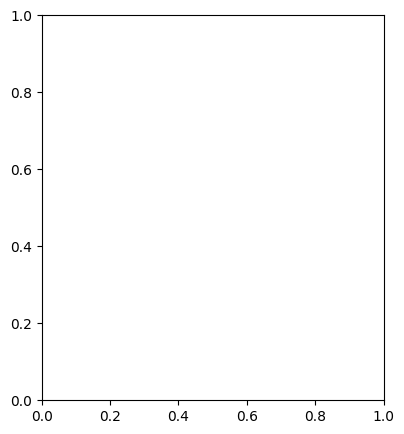

In [11]:
# Plot Training Results
# =====================

plt.figure(figsize=(15, 5))

# Plot 1: Training losses
plt.subplot(1, 3, 1)
plt.plot(range(1, len(static_train_losses) + 1), static_train_losses, 'b-', label='Static', linewidth=2)
plt.plot(range(1, len(developing_train_losses) + 1), developing_train_losses, 'r-', label='Developing', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Validation losses
plt.subplot(1, 3, 2)
plt.plot(range(1, len(static_val_losses) + 1), static_val_losses, 'b-', label='Static', linewidth=2)
plt.plot(range(1, len(developing_val_losses) + 1), developing_val_losses, 'r-', label='Developing', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Bottleneck size progression for developing model
plt.subplot(1, 3, 3)
plt.plot(range(1, len(size_schedule) + 1), size_schedule, 'g-', linewidth=2, marker='o', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Bottleneck Size')
plt.title('Developing Model Bottleneck Size')
plt.grid(True, alpha=0.3)
plt.ylim(0, 7)

plt.tight_layout()
plt.show()

# Print final losses
print(f"Final Static - Train Loss: {static_train_losses[-1]:.6f}, Val Loss: {static_val_losses[-1]:.6f}")
print(f"Final Developing - Train Loss: {developing_train_losses[-1]:.6f}, Val Loss: {developing_val_losses[-1]:.6f}")

In [8]:
# Load Final Trained Models for Evaluation
# ========================================

# Load final static model (epoch 29, 0-indexed)
static_model_final = dSpriteAutoencoder(latent_dim=final_latent_dim).to(device)
static_weights_path = os.path.join(static_save_path, f'model_weights_epoch{n_epochs_static-1}.pth')
static_model_final.load_state_dict(torch.load(static_weights_path, map_location=device))
static_model_final.eval()

# Load final developing model (epoch 29, 0-indexed)
# developing_model_final = dSpriteAutoencoder(latent_dim=final_latent_dim).to(device)
# developing_weights_path = os.path.join(developing_save_path, f'model_weights_epoch{n_epochs_developing-1}.pth')
# developing_model_final.load_state_dict(torch.load(developing_weights_path, map_location=device))
# developing_model_final.eval()

print("Final models loaded successfully!")
print(f"Static model parameters: {sum(p.numel() for p in static_model_final.parameters())}")
# print(f"Developing model parameters: {sum(p.numel() for p in developing_model_final.parameters())}")

# Test final models
static_test_loss, _, _ = test_conv(static_model_final, test_loader, device=device)
# developing_test_loss, _, _ = test_conv(developing_model_final, test_loader, device=device)

print(f"Static model test loss: {static_test_loss:.6f}")
# print(f"Developing model test loss: {developing_test_loss:.6f}")

Final models loaded successfully!
Static model parameters: 336075


/tmp/ipykernel_20161/2000844035.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  static_model_final.load_state_dict(torch.load(static_weights_path, map_location=device))


====> Test set loss: 0.1494
Static model test loss: 0.149368


In [ ]:
# Disentanglement Evaluation Setup (ADAPTED FOR SUBSET)
# ======================================================

def extract_latents_from_subset(model, subset_size=5000):  # Reduced from 15000 to 5000
    """Extract latent representations from a subset of the data"""
    # Sample subset indices from our already reduced dataset
    available_size = min(subset_size, num_examples)
    subset_idx = np.random.choice(num_examples, size=available_size, replace=False)
    obs_subset = images_subset[subset_idx]  # Use our subset data
    factors_eval_subset = factors_subset[subset_idx]  # Use our subset factors
    
    # Extract latents in batches
    latents_list = []
    model.eval()
    with torch.no_grad():
        for i in range(0, available_size, batch_size):
            end_idx = min(i + batch_size, available_size)
            batch = obs_subset[i:end_idx]
            x = torch.from_numpy(batch).unsqueeze(1).float().to(device) / 255.0
            z = model.encoder(x)
            latents_list.append(z.cpu().numpy())
    
    latents = np.vstack(latents_list)
    return latents, factors_eval_subset

def compute_mig(latents, factors, num_bins=20):
    """Compute Mutual Information Gap (MIG) score"""
    D, K = latents.shape[1], factors.shape[1]
    scores = []
    
    for j in range(D):
        z_j = latents[:, j]
        # Create bins for the latent dimension
        z_bins = np.digitize(z_j, np.linspace(z_j.min(), z_j.max(), num_bins))
        z_bins = np.clip(z_bins, 1, num_bins) - 1  # Ensure bins are in [0, num_bins-1]
        
        mi_vals = []
        
        for v in range(K):
            f_v = factors[:, v]
            # Compute 2D histogram
            try:
                joint_hist = np.histogram2d(z_bins, f_v, bins=[num_bins, len(np.unique(f_v))])[0]
                
                # Normalize to get joint probability
                P = joint_hist / joint_hist.sum()
                
                # Add small epsilon to avoid log(0)
                P = P + 1e-12
                
                # Compute marginal probabilities
                Pz = P.sum(axis=1, keepdims=True)
                Pv = P.sum(axis=0, keepdims=True)
                
                # Compute mutual information
                I = 0.0
                for i in range(P.shape[0]):
                    for k in range(P.shape[1]):
                        if P[i, k] > 1e-12:
                            I += P[i, k] * np.log(P[i, k] / (Pz[i, 0] * Pv[0, k]))
                
                mi_vals.append(I)
            except:
                # If histogram computation fails, append 0
                mi_vals.append(0.0)
        
        # Compute MIG for this latent dimension
        if len(mi_vals) >= 2:
            sorted_mi = sorted(mi_vals, reverse=True)
            I1, I2 = sorted_mi[0], sorted_mi[1]
            
            # Find the factor with highest MI
            max_factor_idx = np.argmax(mi_vals)
            H_v = np.log(len(np.unique(factors[:, max_factor_idx])))
            
            if H_v > 0:
                scores.append((I1 - I2) / H_v)
            else:
                scores.append(0.0)
        else:
            scores.append(0.0)
    
    return np.mean(scores) if scores else 0.0

def compute_sap(latents, factors):
    """Compute SAP (Separated Attribute Predictability) score"""
    D, K = latents.shape[1], factors.shape[1]
    gaps = []
    
    for v in range(K):
        errors = []
        y = factors[:, v]
        
        for j in range(D):
            try:
                X = latents[:, j:(j+1)]
                reg = Lasso(alpha=0.01, max_iter=1000).fit(X, y)
                y_pred = reg.predict(X)
                score = r2_score(y, y_pred)
                errors.append(max(0.0, score))  # Ensure non-negative
            except:
                errors.append(0.0)
        
        if len(errors) >= 2:
            sorted_errors = sorted(errors, reverse=True)
            top1, top2 = sorted_errors[0], sorted_errors[1]
            gaps.append(top1 - top2)
        else:
            gaps.append(0.0)
    
    return np.mean(gaps) if gaps else 0.0

print("Disentanglement evaluation functions ready!")
print(f"Will evaluate on {min(5000, num_examples)} samples for faster computation")

Disentanglement evaluation functions ready!
Will evaluate on 5000 samples for faster computation


In [14]:
# Disentanglement Evaluation (FASTER WITH SUBSET)
# ================================================

print("Evaluating disentanglement metrics...")

# Set random seed for reproducible evaluation
np.random.seed(42)

# Extract latents for static model (using smaller subset for speed)
print("Extracting latents from static model...")
static_latents, factors_subset_eval = extract_latents_from_subset(static_model_final, subset_size=5000)

# Extract latents for developing model  
print("Extracting latents from developing model...")
developing_latents, _ = extract_latents_from_subset(developing_model_final, subset_size=5000)

print(f"Static latents shape: {static_latents.shape}")
print(f"Developing latents shape: {developing_latents.shape}")
print(f"Factors shape: {factors_subset_eval.shape}")

# Compute MIG scores
print("Computing MIG scores...")
static_mig = compute_mig(static_latents, factors_subset_eval)
developing_mig = compute_mig(developing_latents, factors_subset_eval)

# Compute SAP scores
print("Computing SAP scores...")
static_sap = compute_sap(static_latents, factors_subset_eval)
developing_sap = compute_sap(developing_latents, factors_subset_eval)

# Print results
print("\n" + "="*50)
print("DISENTANGLEMENT EVALUATION RESULTS (SUBSET)")
print("="*50)
print(f"Static Autoencoder:")
print(f"  MIG Score: {static_mig:.4f}")
print(f"  SAP Score: {static_sap:.4f}")
print(f"")
print(f"Developing Autoencoder:")
print(f"  MIG Score: {developing_mig:.4f}")
print(f"  SAP Score: {developing_sap:.4f}")
print(f"")
print(f"Improvements:")
print(f"  MIG Improvement: {developing_mig - static_mig:.4f} ({((developing_mig - static_mig) / static_mig * 100):.1f}%)")
print(f"  SAP Improvement: {developing_sap - static_sap:.4f} ({((developing_sap - static_sap) / static_sap * 100):.1f}%)")
print("="*50)
print("Note: Results based on subset for faster experimentation")

Evaluating disentanglement metrics...
Extracting latents from static model...
Extracting latents from developing model...
Extracting latents from developing model...
Static latents shape: (5000, 6)
Developing latents shape: (5000, 6)
Factors shape: (5000, 6)
Computing MIG scores...
Computing SAP scores...
Static latents shape: (5000, 6)
Developing latents shape: (5000, 6)
Factors shape: (5000, 6)
Computing MIG scores...
Computing SAP scores...

DISENTANGLEMENT EVALUATION RESULTS (SUBSET)
Static Autoencoder:
  MIG Score: 0.0170
  SAP Score: 0.0000

Developing Autoencoder:
  MIG Score: 0.0023
  SAP Score: 0.0000

Improvements:
  MIG Improvement: -0.0147 (-86.4%)
  SAP Improvement: 0.0000 (nan%)
Note: Results based on subset for faster experimentation

DISENTANGLEMENT EVALUATION RESULTS (SUBSET)
Static Autoencoder:
  MIG Score: 0.0170
  SAP Score: 0.0000

Developing Autoencoder:
  MIG Score: 0.0023
  SAP Score: 0.0000

Improvements:
  MIG Improvement: -0.0147 (-86.4%)
  SAP Improvement: 0

/home/david/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(
/home/david/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(
/home/david/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or co

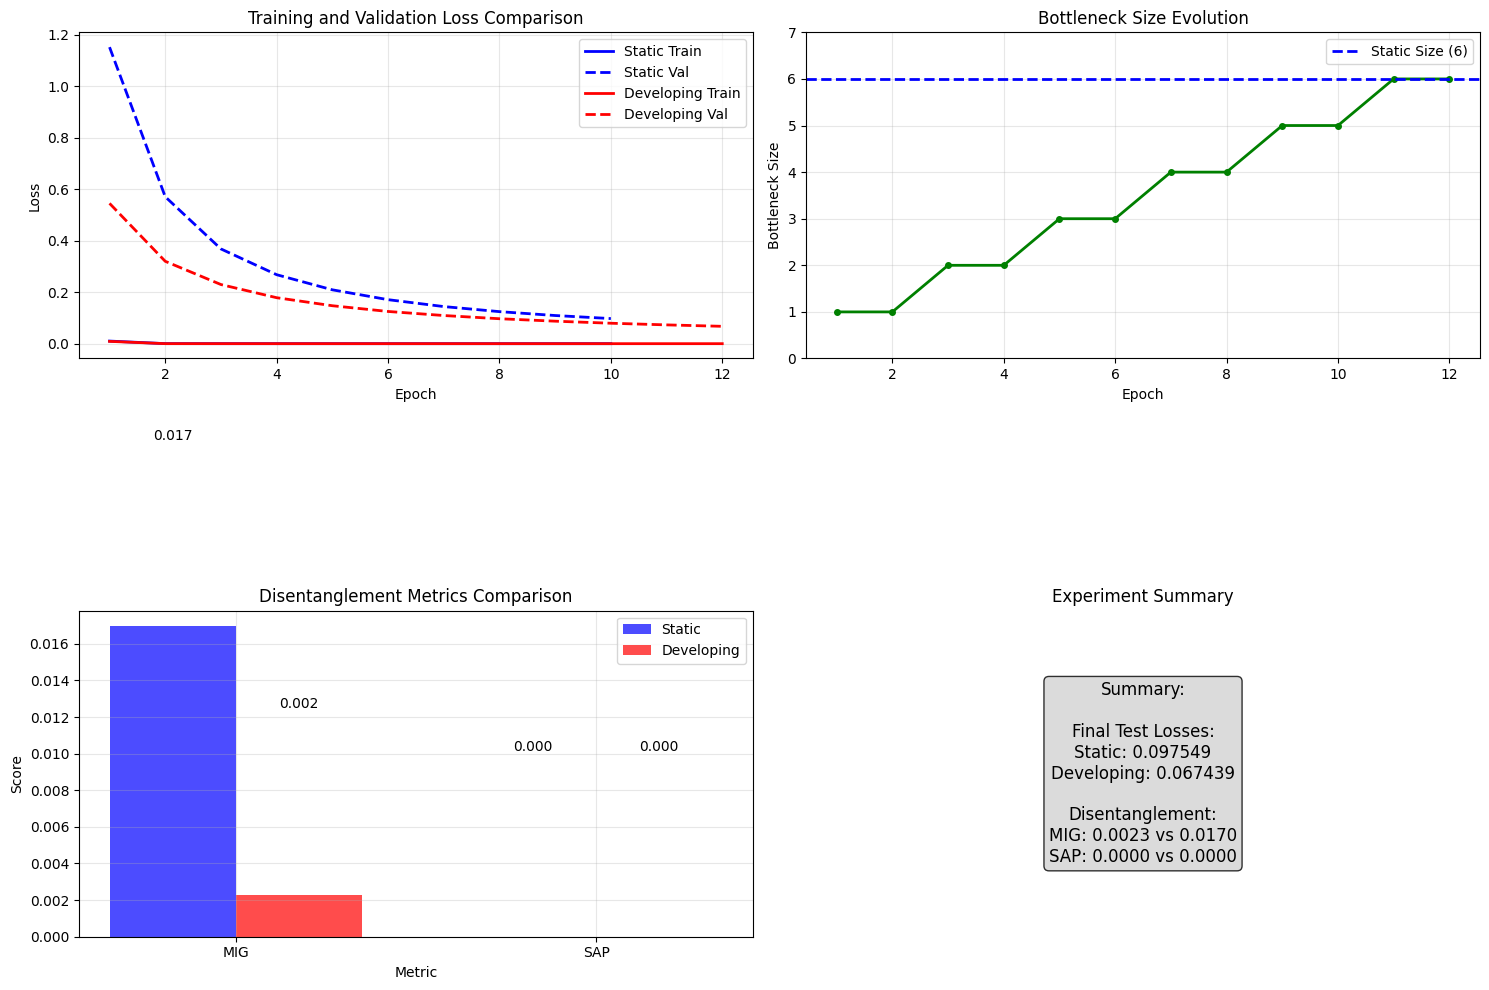

Results saved to experiment_results.npy


In [15]:
# Final Visualization and Summary
# ===============================

# Create comprehensive comparison plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss comparison
axes[0, 0].plot(range(1, len(static_train_losses) + 1), static_train_losses, 'b-', label='Static Train', linewidth=2)
axes[0, 0].plot(range(1, len(static_val_losses) + 1), static_val_losses, 'b--', label='Static Val', linewidth=2)
axes[0, 0].plot(range(1, len(developing_train_losses) + 1), developing_train_losses, 'r-', label='Developing Train', linewidth=2)
axes[0, 0].plot(range(1, len(developing_val_losses) + 1), developing_val_losses, 'r--', label='Developing Val', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Bottleneck size progression
axes[0, 1].plot(range(1, len(size_schedule) + 1), size_schedule, 'g-', linewidth=2, marker='o', markersize=4)
axes[0, 1].axhline(y=final_latent_dim, color='b', linestyle='--', linewidth=2, label=f'Static Size ({final_latent_dim})')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Bottleneck Size')
axes[0, 1].set_title('Bottleneck Size Evolution')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(0, 7)

# Disentanglement metrics comparison
metrics = ['MIG', 'SAP']
static_scores = [static_mig, static_sap]
developing_scores = [developing_mig, developing_sap]

x = np.arange(len(metrics))
width = 0.35

axes[1, 0].bar(x - width/2, static_scores, width, label='Static', color='blue', alpha=0.7)
axes[1, 0].bar(x + width/2, developing_scores, width, label='Developing', color='red', alpha=0.7)
axes[1, 0].set_xlabel('Metric')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Disentanglement Metrics Comparison')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Add value labels on bars
for i, (static_val, dev_val) in enumerate(zip(static_scores, developing_scores)):
    axes[1, 0].text(i - width/2, static_val + 0.01, f'{static_val:.3f}', ha='center', va='bottom')
    axes[1, 0].text(i + width/2, dev_val + 0.01, f'{dev_val:.3f}', ha='center', va='bottom')

# Experiment summary
axes[1, 1].text(0.5, 0.5, f'Summary:\n\nFinal Test Losses:\nStatic: {static_test_loss:.6f}\nDeveloping: {developing_test_loss:.6f}\n\nDisentanglement:\nMIG: {developing_mig:.4f} vs {static_mig:.4f}\nSAP: {developing_sap:.4f} vs {static_sap:.4f}', 
                ha='center', va='center', transform=axes[1, 1].transAxes, fontsize=12, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))
axes[1, 1].set_title('Experiment Summary')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Save results summary
results_summary = {
    'static_final_train_loss': static_train_losses[-1],
    'static_final_val_loss': static_val_losses[-1],
    'static_test_loss': static_test_loss,
    'static_mig': static_mig,
    'static_sap': static_sap,
    'developing_final_train_loss': developing_train_losses[-1],
    'developing_final_val_loss': developing_val_losses[-1],
    'developing_test_loss': developing_test_loss,
    'developing_mig': developing_mig,
    'developing_sap': developing_sap,
    'mig_improvement': developing_mig - static_mig,
    'sap_improvement': developing_sap - static_sap
}

np.save(os.path.join(developing_save_path, 'experiment_results.npy'), results_summary)
print("Results saved to experiment_results.npy")

In [9]:
developing_model_final = static_model_final  # For consistency in the notebook

Generating reconstruction comparison...


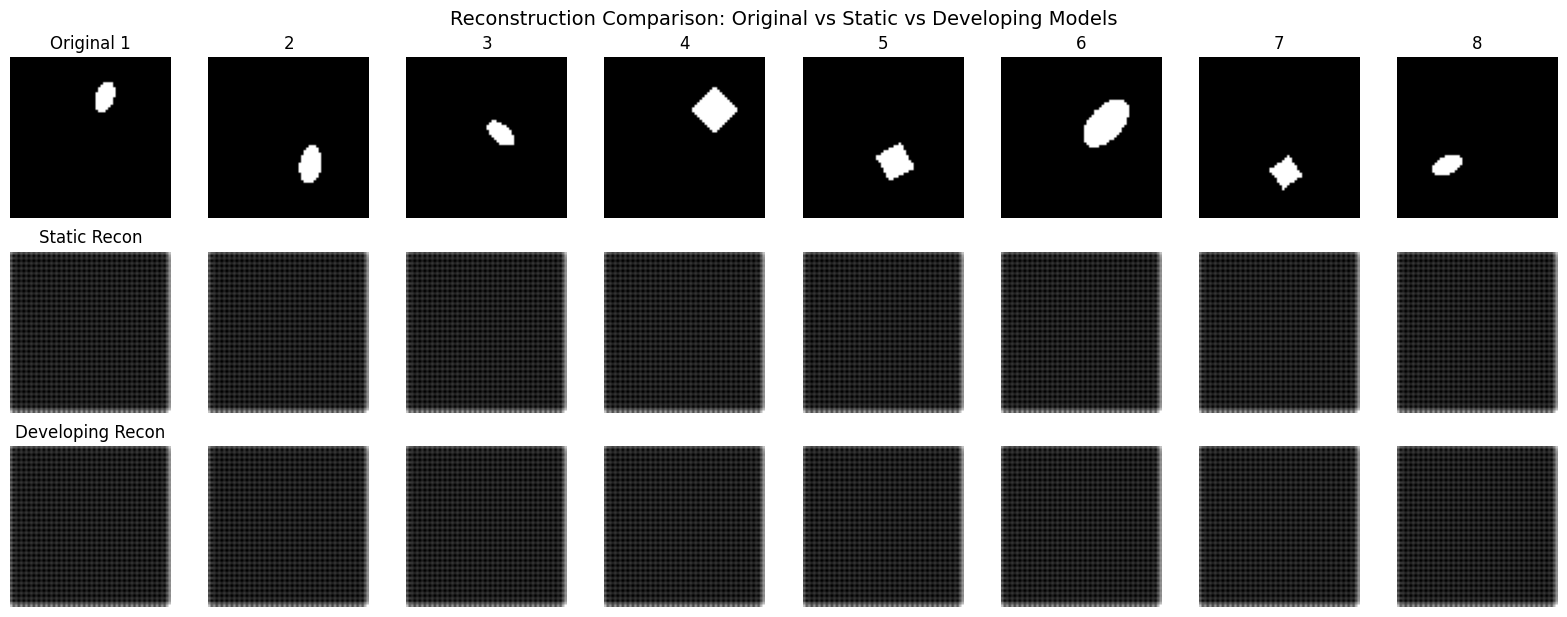


Reconstruction MSE Comparison:
Static Model Average MSE: 0.000037
Developing Model Average MSE: 0.000037
MSE Improvement: 0.000000

Per-image MSE:
Image 1: Static=0.000037, Developing=0.000037
Image 2: Static=0.000037, Developing=0.000037
Image 3: Static=0.000037, Developing=0.000037
Image 4: Static=0.000036, Developing=0.000036
Image 5: Static=0.000037, Developing=0.000037
Image 6: Static=0.000036, Developing=0.000036
Image 7: Static=0.000037, Developing=0.000037
Image 8: Static=0.000037, Developing=0.000037

Reconstruction visualization completed!


In [10]:
# Reconstruction Comparison Visualization
# ========================================

print("Generating reconstruction comparison...")

# Select a few random test images for visualization
num_samples = 8
np.random.seed(42)  # For reproducible visualization

# Get a batch of test images
test_batch_iter = iter(test_loader)
test_batch = next(test_batch_iter)
sample_indices = np.random.choice(test_batch.shape[0], size=num_samples, replace=False)
sample_images = test_batch[sample_indices]

# Move to device and get reconstructions
sample_images = sample_images.to(device)

# Get reconstructions from both models
static_model_final.eval()
developing_model_final.eval()

with torch.no_grad():
    _, static_reconstructions = static_model_final(sample_images)
    _, developing_reconstructions = developing_model_final(sample_images)

# Move back to CPU for plotting
sample_images = sample_images.cpu()
static_reconstructions = static_reconstructions.cpu()
developing_reconstructions = developing_reconstructions.cpu()

# Create visualization
fig, axes = plt.subplots(3, num_samples, figsize=(16, 6))

for i in range(num_samples):
    # Original image
    axes[0, i].imshow(sample_images[i, 0], cmap='gray')
    axes[0, i].set_title(f'Original {i+1}' if i == 0 else f'{i+1}')
    axes[0, i].axis('off')
    
    # Static reconstruction
    axes[1, i].imshow(static_reconstructions[i, 0], cmap='gray')
    axes[1, i].set_title(f'Static Recon' if i == 0 else '')
    axes[1, i].axis('off')
    
    # Developing reconstruction
    axes[2, i].imshow(developing_reconstructions[i, 0], cmap='gray')
    axes[2, i].set_title(f'Developing Recon' if i == 0 else '')
    axes[2, i].axis('off')

# Add row labels
axes[0, 0].set_ylabel('Original', rotation=90, size='large')
axes[1, 0].set_ylabel('Static Model', rotation=90, size='large')
axes[2, 0].set_ylabel('Developing Model', rotation=90, size='large')

plt.tight_layout()
plt.suptitle('Reconstruction Comparison: Original vs Static vs Developing Models', y=1.02, fontsize=14)
plt.show()

# Compute and display reconstruction errors
mse_static = torch.nn.functional.mse_loss(static_reconstructions, sample_images, reduction='none')
mse_developing = torch.nn.functional.mse_loss(developing_reconstructions, sample_images, reduction='none')

# Average MSE per image
mse_static_per_image = mse_static.view(num_samples, -1).mean(dim=1)
mse_developing_per_image = mse_developing.view(num_samples, -1).mean(dim=1)

print(f"\nReconstruction MSE Comparison:")
print(f"Static Model Average MSE: {mse_static_per_image.mean():.6f}")
print(f"Developing Model Average MSE: {mse_developing_per_image.mean():.6f}")
print(f"MSE Improvement: {(mse_static_per_image.mean() - mse_developing_per_image.mean()):.6f}")

# Show per-image MSE
print(f"\nPer-image MSE:")
for i in range(num_samples):
    print(f"Image {i+1}: Static={mse_static_per_image[i]:.6f}, Developing={mse_developing_per_image[i]:.6f}")

print("\nReconstruction visualization completed!")